## **Building with a Neural-net**

Happens in the following steps

1. design model (input, and output sizes as well as forward pass)
2. Construct loss and optimizer
3. Training loop
- Forward pass
- backward pass (gradients)
- update weights

In [1]:
import sys
import os
import torch
from torch.utils.data import DataLoader, TensorDataset,random_split
import pandas as pd


In [2]:
sys.path.append(os.path.abspath('../'))

In [3]:
from pipelines.customize_dataset import customize_dataset
df_raw = pd.read_csv('../../data/processed/Final_dataset.csv')
df = customize_dataset(df_raw,random_string="random word")
df.head()

,area,year,average_rain_fall_mm_per_year,crops,crop_yields,pesticide_tonnes,avg_temp
2303,Bangladesh,1947.76,2666.0,Sweet potatoes,107019.0,12936.50,26.00
12381,India,1940.00,1083.0,Soybeans,9044.2,44957.52,25.62
4413,Brazil,1948.73,1761.0,Yams,104058.9,335742.00,20.78
27082,Turkey,1950.67,593.0,Soybeans,42574.4,39534.43,11.60
19841,Mexico,1943.88,758.0,Sorghum,42045.3,26433.14,24.92


In [4]:
input_cols = ['area','year','average_rain_fall_mm_per_year', 'crops','pesticide_tonnes','avg_temp']
output_cols = ['crop_yields']
categorical_cols =['area','crops']

In [5]:
from pipelines.customize_dataset import dataframe_to_arrays
inputs_array, targets_array = dataframe_to_arrays(df, input_cols= input_cols, output_cols= output_cols, categorical_cols=categorical_cols)

In [6]:
# scale features before converting to tensors
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
inputs_array = scaler.fit_transform(inputs_array)

In [7]:
df.shape

(26829, 7)

In [8]:
inputs = torch.Tensor(inputs_array)
targets = torch.Tensor(targets_array)

dataset = TensorDataset(inputs, targets)
train_ds, val_ds= random_split(dataset, [12000,14829])
batch_size = 130

train_loader = DataLoader(train_ds, batch_size, shuffle = True)
val_loader = DataLoader(val_ds, batch_size)

In [9]:
input_size = len(input_cols)
output_size= len(output_cols)

In [10]:
from pipelines.train_and_evaluate import CropYieldModel
model = CropYieldModel(input_size=input_size, output_size=output_size)

In [11]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.1851,  0.3878, -0.3460,  0.2589, -0.2130, -0.3279],
         [-0.2162, -0.1335, -0.1198,  0.3859,  0.1176,  0.3638],
         [-0.1362, -0.2824,  0.1544,  0.4052,  0.3623, -0.3522],
         [-0.1515,  0.2758, -0.1997,  0.2647, -0.3417,  0.1082],
         [-0.3311, -0.2673,  0.3260,  0.3701,  0.3940, -0.2064],
         [ 0.0605,  0.1706, -0.3063, -0.2422, -0.1628, -0.0405],
         [-0.3683,  0.2369,  0.3711,  0.0193, -0.2190, -0.1612],
         [ 0.3055,  0.2521,  0.0406, -0.1690, -0.2467, -0.0426],
         [ 0.3150,  0.2423, -0.2756,  0.3139,  0.3698, -0.1520],
         [-0.1935, -0.4065,  0.2800, -0.0499,  0.1358, -0.2698],
         [ 0.3560,  0.2915,  0.2782,  0.1863,  0.3516,  0.2211],
         [ 0.4052, -0.1364, -0.2184, -0.3337, -0.0918,  0.3243],
         [ 0.0341, -0.0551,  0.3653, -0.2542,  0.1866, -0.1362],
         [-0.0900, -0.0696,  0.2624, -0.3810,  0.2584, -0.0475],
         [-0.0989,  0.0086,  0.2244, -0.0129,  0.2370, -0.1148],
  

In [12]:
from pipelines.train_and_evaluate import evaluate

result = evaluate(model=model, val_loader= val_loader)
print(result)

{'val_loss': 84212.125}


In [13]:
from pipelines.train_and_evaluate import fit
epochs = 1700
lr = 1e-3

history_current = fit(epochs= epochs, lr = lr, model = model, train_loader=train_loader, val_loader=val_loader, opt_func = torch.optim.Adam)

Epoch[20], val_loss: 60111.9922
Epoch[40], val_loss: 58847.6797
Epoch[60], val_loss: 58160.1016
Epoch[80], val_loss: 57834.3828
Epoch[100], val_loss: 57640.8164
Epoch[120], val_loss: 57471.3359
Epoch[140], val_loss: 57291.3633
Epoch[160], val_loss: 56991.5547
Epoch[180], val_loss: 56481.1016
Epoch[200], val_loss: 55751.2656
Epoch[220], val_loss: 54807.3125
Epoch[240], val_loss: 53665.8711
Epoch[260], val_loss: 52341.4883
Epoch[280], val_loss: 50871.9766
Epoch[300], val_loss: 49276.9570
Epoch[320], val_loss: 47571.5664
Epoch[340], val_loss: 45727.8867
Epoch[360], val_loss: 43998.2188
Epoch[380], val_loss: 42504.1914
Epoch[400], val_loss: 41532.3242
Epoch[420], val_loss: 40839.0703
Epoch[440], val_loss: 40299.3398
Epoch[460], val_loss: 39863.4961
Epoch[480], val_loss: 39492.0703
Epoch[500], val_loss: 39154.1523
Epoch[520], val_loss: 38854.7266
Epoch[540], val_loss: 38591.1172
Epoch[560], val_loss: 38271.7031
Epoch[580], val_loss: 37971.5039
Epoch[600], val_loss: 37684.5391
Epoch[620], va

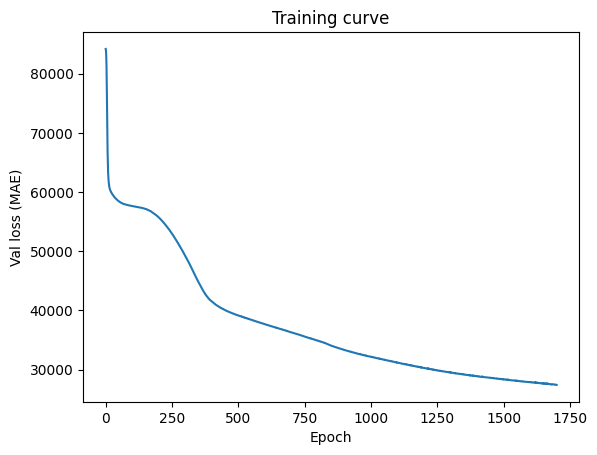

In [14]:
import matplotlib.pyplot as plt
losses = [x['val_loss'] for x in history_current]
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Val loss (MAE)')
plt.title('Training curve')
plt.show()

In [15]:
baseline = (targets - targets.mean()).abs().mean()
model_mae = 30733.3418
print(f'Baseline MAE: {baseline:.1f}')
print(f'Model MAE: {model_mae:.1f}')

Baseline MAE: 70495.5
Model MAE: 30733.3


In [16]:
from pipelines.train_and_evaluate import predict_single
input, target = val_ds[0] #change index to test repeatedly, and see how good model is
predict_single(input=input, target= target, model =model)

Input:  tensor([ 1.0261,  0.7714,  2.8073,  0.2188, -0.6160,  0.7381])
Target:  tensor([37612.3008])
Prediction:  tensor([15070.7100])


In [17]:
# save the scaler
import joblib

joblib.dump(scaler, '../models/NN_Models/scaler.pkl')

# save category mappings
area_mapping = dict(enumerate(df['area'].astype('category').cat.categories))
crops_mapping = dict(enumerate(df['crops'].astype('category').cat.categories))

joblib.dump({'area':area_mapping, 'crops':crops_mapping},'../models/NN_Models/category_mappings.pkl')

torch.save(model.state_dict(), '../models/NN_Models/neural_net.pth')

In [18]:
import numpy as np

# Collect all val inputs and targets from the loader
val_inputs = []
val_targets = []
for batch in val_loader:
    inputs_b, targets_b = batch
    val_inputs.append(inputs_b.numpy())
    val_targets.append(targets_b.numpy())

X_val = np.concatenate(val_inputs, axis=0)
y_val = np.concatenate(val_targets, axis=0)

In [19]:
from pipelines.train_and_evaluate import calc_r2_score
calc_r2_score(model, X_val, y_val.ravel())  

r2_score: 0.7057
